# A Rota da Acadêmica: Redes neurais informadas por física

**Por**: Brenda L. Abrunhosa

*11/05/2026*

## Sumário

1. [Introdução](#introdução)
2. [Quando usar PINNs?](#quando-usar-pinns)
3. [Como integrar física em redes neurais?](#como-integrar-física-em-redes-neurais)

    3.1. [Função de custo](#função-de-custo)

    3.2. [Otimizador L-BFGS](#otimizador-l-bfgs)
4. [Exemplo básico com `pytorch`](#exemplo-básico-com-pytorch)
5. [Como as PINNs lidam com problemas inversos?](#como-as-pinns-lidam-com-problemas-inversos)
6. [PINNs usando a biblioteca `DeepXDE`](#pinns-usando-a-biblioteca-deepxde)
7. [Resolvendo uma EDO com `DeepXDE`](#resolvendo-uma-edo-com-deepxde)

8. [Resolvendo uma PDE com `DeepXDE`](#resolvendo-uma-pde-com-deepxde)
9. [Limitações das PINNs](#limitações-das-pinns)

    9.1. [*Spectral Bias*](#spectral-bias)

    9.2. [*Stiff Differentiation*](#stiff-differentiation)
    
    9.3. [*Curse of Dimentionality*](#curse-of-dimentionality)
10. [Conclusão](#conclusão)
11. [Referências](#referências)

## 1. Introdução

O objetivo desse notebook é explorar as PINNs: redes neurais informadas por física (*physics informed neural networks*). As PINNs, introduzidas por M. Raissi, P. Perdikaris e G.E. Karniadakis em um artigo de 2018 [1], tem despertado grande interesse em diversas áreas da ciência computacional e da física. Como exposto pelo professor doutor José Mario Martinez, a motivação para isso é combinar a possibilidade de aproximação de redes neurais com o conhecimento físico já estabelecido por meio de equações diferenciais. 

Tradicionalmente, problemas governados por equações diferenciais são resolvidos por métodos numéricos, como diferenças finitas. Embora eficazes, esses métodos apresentam algumas limitações, como a necessidade de discretização do domínio por malhas, custos computacionais elevados e dificuldades em lidar com condições de contorno não usuais.

Por outro lado, abordagens puramente baseadas em aprendizado de máquina dependem fortemente de grandes quantidades de dados e não garantem que as soluções obtidas respeitem leis físicas fundamentais. Isso pode levar a previsões inconsistentes ou até fisicamente impossíveis. E é nesse ponto que torna-se clara a relevância das PINNs, sendo uma alternativa para utilizar redes neurais garantindo que as leis físicas vigentes sejam respeitadas.

Nesse notebook, será exposta a ideia por trás da PINN, explorando tanto problemas diretos (onde a equação diferencial é conhecida) quanto inversos (onde buscamos inferir parâmetros físicos). Será implementada uma PINN do zero com `PyTorch` para entender seus mecanismos internos, e em seguida será utilizado a biblioteca `DeepXDE` para resolver problemas mais complexos, incluindo uma equação diferencial parcial (PDE). Por fim, serão apresentadas algumas limitações dessa abordagem.

Os pré-requisitos para acompanhar esse notebook incluem:
- arquitetura MLP, backpropagation e funções de ativação;
- compreensão do que são equações diferenciais, condições iniciais e de contorno;
- familiaridade com autograd e loops de treinamento;
- conceito de derivadas.

E outros tópicos semelhantes.

## 2. Quando usar PINNs?

As PINNs se fazem úteis quando se deseja solucionar uma equação diferencial em problemas físicos. Para entender quando elas são relevantes, vale classificar problemas físicos em 3 tipos [2]:

1. Grande quantidade de dados, mas leis físicas desconhecidas;
2. Poucos dados, mas leis físicas bem conhecidas;
3. Quantidade moderada de dados e determinado conhecimento da física;

No primeiro caso, a ausência de restrições físicas pode levar a soluções inconsistentes. No segundo, a falta de dados pode limitar a modelagem. Já no terceiro, tipo de problema no qual se aplica as PINNs, pode-se combinar dados e leis físicas, resultando em soluções fisicamente consistentes [3].

Pode-se entender isso com o seguinte exemplo, retirado de um vídeo e material do canal Vizuara [4], que será utilizado ao longo deste notebook:

Lançamos uma bola obliquamente. Pela física Newtoniana, sabemos que ela deve percorrer uma trajetória parabólica. Caso, porém, o dataset obtido experimentalmente não possua grande volume de dados, e talvez dados não tão bons, pode-se obter algo como o seguinte:

![Gráfico de altura por tempo de um lançamento oblíquo](alturaxtempo_com_defeito.png)

**Figura 1**: Gráfico da altura por tempo em um lançamento oblíquo

**Fonte**: https://www.vizuaranewsletter.com/p/teach-your-neural-network-to-respect?utm_campaign=post&utm_medium=web

O gráfico mostra a altura conforme o passar do tempo nesse lançamento oblíquo. Percebe-se que há um ponto que não segue a tendência parabólica dos outros. Se conhecemos a física, fica claro que esse é um erro experimental. Caso desconhecida, a rede pode passar a interpretar esse tipo de variação de um determinado dataset, advinda de ruídos e erros, como novos padrões a serem generalizados.

![Gráfico da previsão](alturaxtempo_previsap.png)

**Figura 2**: Gráfico dos dados experimentais e da previsão de uma rede neural de um lançamento oblíquo

**Fonte**: https://www.vizuaranewsletter.com/p/teach-your-neural-network-to-respect?utm_campaign=post&utm_medium=web

Por isso que as PINNs, mesmo em datasets menores, conseguem oferecer boas predições. Afinal, não consideram esses problemas dos dados como algo a ser aprendido, limitando os possíveis resultados a valores coerentes, como perceptível na imagem abaixo:

![Gráfico da previsão](completasso.png)

**Figura 3**: Comparação das previsões relacionadas a um lançamento oblíquo

**Fonte**: https://www.vizuaranewsletter.com/p/teach-your-neural-network-to-respect?utm_campaign=post&utm_medium=web

## 3. Como integrar física em redes neurais?

A ideia é, ao invés de treinar uma rede neural para ajustar dados, treinar uma rede para satisfazer a uma equação diferencial. A rede recebe coordenadas como entrada e retorna a quantidade física de interesse como saída. A física é imposta através da função de custo, que penaliza violações da equação diferencial por meio do resíduo da equação. Ou seja, a rede aprende uma função que não apenas se ajusta aos dados observados, mas também respeita as leis físicas que governam o sistema. [3]

Vamos utilizar como exemplo o lançamento oblíquo. Sabemos que a física do problema, descrita por uma equação diferencial, obedece ao seguinte:

$$\frac{dh}{dt}=v_0 - gt$$

Onde $h$ é a altura, $t$ o tempo, $v_0$ a velocidade inicial e $g$ a aceleração da gravidade [4].

### 3.1. Função de custo

A função de custo, ou perda, de uma PINN ($L$) é dada por um termo correpondente à função diferencial $L_{física}$, e outro relacionado a condições experimentais ($L_{dados}$):

$$L = L_{dados} + L_{física}$$

O erro relacionado aos dados já é bastante conhecido, sendo ele justamente o que a rede neural tradicionalmente tenta minimizar [4]. Pode-se comparar o valor real de um dado com o da previsão da rede neural somando o quadrado das diferenças em cada ponto e dividindo pelo número total de pontos:

$$L_{dados} = \frac{1}{N} \sum_{i=1}^N (y_i-\hat{y_i}))^2$$

Ou seja, é a média do quadrado dos erros, garantindo que os erros não se cancelem, já que não serão negativos, além de ser diferenciável [4].

Já o termo $L_{física}$ é o diferencial da PINN. Na mesma lógica da função de perda anterior:

$$L_{física} = \frac{1}{N} \sum_{i=1}^N (\frac{dh}{dt}-\frac{d\hat{h}}{dt})^2$$

Aqui é necessário fazer uma observação. Como que a rede prevê $\frac{dh}{dt}$? A resposta está na diferenciação automática, ou AD, Automatic Differentiation [4]. O `PyTorch` permite que a saída da rede seja derivada em relação ao tempo.

Considerando uma função genérica:

$$F(u)=0$$

A rede neural fornece uma aproximação $u_\theta(x)$, que, substituída na equação diferencial, retorna o resíduo:

$$r(x)=F(u_\theta(x))$$

Nota-se que, se a solução fosse exata, teríamos $r(x) = 0$ para todo $x$. No entanto, como a rede fornece apenas uma aproximação, esse valor não será nulo. Para o exemplo, considerando $h_\theta$ a aproximação da rede para a altura:

$$L_{física} = \frac{1}{N} \sum_{i=1}^N (\frac{dh}{dt}-\frac{dh_\theta}{dt})^2$$

Assim, define-se o erro como a média do quadrado do resíduo em um conjunto de pontos do domínio:

$$L_{física} = \frac{1}{N} \sum_{i=1}^N r(h_i)^2$$

Ou seja, este termo mede o quanto a rede viola a equação diferencial, sendo o principal *insight* por trás das PINNs [4].

Vale ressaltar que os pontos $h_i$ utilizados no cálculo do resíduo são chamados de *collocation points*. Esses pontos representam posições do domínio onde a PINN verifica o quanto a solução prevista viola a equação diferencial. Ou seja, são os pontos nos quais a física do problema é imposta durante o treinamento. Em uma EDO, esses pontos normalmente correspondem a diferentes instantes de tempo. Já em PDEs, podem corresponder simultaneamente a posições espaciais e instantes temporais. A escolha da quantidade e distribuição desses pontos é extremamente importante, pois poucos *collocation points* podem impedir que a rede aprenda corretamente a física do problema, enquanto quantidades excessivas aumentam significativamente o custo computacional. [6]

Entretanto, apenas minimizar essa perda baseada nesses dois termos não é suficiente. A rede precisa também obedecer às condições iniciais do problema, como a altura inicial e a velocidade inicial. Para tanto, pode-se adicionar um novo termo de perda relacionado às condições iniciais ($L_{ic}$), garantindo que a solução aprendida seja fisicamente consistente desde o instante inicial [4]. Na realidade, então, a função de perda se torna algo do tipo:

$$L = L_{dados} + L_{física} + L_{ic}$$

onde pode-se descrever $L_{ic}$, nesse caso, como:

$$L{ic} = [y(t=0)-\hat{y}(t=0)]^2 = [h(0)-\hat{h}(0)]^2$$

Além disso, em casos nos quais existem condições de contorno, também é necessário incorporá-las à função de perda. Enquanto as condições iniciais descrevem o estado do sistema em um instante inicial, as condições de contorno descrevem o comportamento da solução nas bordas do domínio espacial (o que não ocorre no nosso exemplo). [4]

Por exemplo, na equação do calor em uma barra unidimensional [5]:

$$\frac{\partial u}{\partial t}=\alpha\frac{\partial^2u}{\partial x^2}$$

pode-se impor que as extremidades da barra permaneçam a temperatura nula:

$$u(0,t)=0$$

$$u(L,t)=0$$

Essas equações representam condições de contorno, pois especificam o valor da solução nas bordas espaciais do sistema. Assim como ocorre para as condições iniciais, pode-se definir um termo de perda associado às condições de contorno ($L_{bc}$) [6]:

$$L_{bc} = \frac{1}{N}\sum_{i=1}^{N}(u(x_{bc},t)-\hat{u}(x_{bc},t))^2$$

onde $x_{bc}$ representa pontos localizados na fronteira do domínio, $u(x_{bc},t)$ corresponde ao valor físico esperado e $\hat{u}(x_{bc},t)$ representa a previsão da rede neural, resultando em:

$$L = L_{dados} + L_{física} + L_{ic} + L_{bc}$$

Mas ainda tem algo faltando. Será que é razoável considerar todos esses pesos igualmente? Sabendo que eles podem estar em ordens de grandeza diferente, além das especificidades de cada conjunto de dados, vale utilizar coeficientes $\lambda$ para controlar a contribuição relativa de cada treino durante o treinamento. Isso nos leva à expressão completa da perda:

$$L = \lambda_1L_{dados} + \lambda_2L_{física} + \lambda_3L_{ic} + \lambda_4L_{bc}$$

A combinação desses termos permite que a PINN aprenda soluções fisicamente consistentes mesmo em cenários com poucos dados disponíveis.

Essa abordagem é chamada de *soft constraint*, pois as restrições são satisfeitas aproximadamente. Outra possibilidade consiste em impor condições exatamente. Essa abordagem, *hard constraint*, pode ser feita construindo uma *trial function* que satisfaça automaticamente as condições de contorno. Essa abordagem elimina a necessidade de termos adicionais na função de custo para as condições impostas. [7]

### 3.2. Otimizador L-BFGS

Em redes neurais, é comum utilizar o otimizador Adam, que combina as ideias de momento com a adaptação individual da taxa de aprendizado para cada parâmetro da rede. Isso geralmente fornece convergência rápida e boa estabilidade durante o treinamento. Quando, porém, se trata de PINNs, vale mencionar o método *quasi*-Newton L-BFGS (*Limited-memory Broyden–Fletcher–Goldfarb–Shanno*). Diferentemente do Adam, o L-BFGS utiliza aproximações da Hessiana da função de perda, isto é, informações relacionadas à curvatura da superfície de otimização. A Hessiana da função de perda é uma matriz formada pelas segundas derivadas da perda em relação aos parâmetros da rede neural. Enquanto o gradiente indica a direção de maior crescimento da função, a Hessiana fornece informações sobre sua curvatura. Isso permite passos de atualização mais precisos. [8]

Matematicamente, métodos *quasi*-Newton realizam atualizações dos parâmetros utilizando aproximações da Hessiana:

$$x_{k+1}=x_k-\beta_k H_k \nabla F(x_k)$$

onde $x_k$ representa os parâmetros da rede na iteração $k$, $\nabla F(x_k)$ é o gradiente da função de perda, $\beta_k$ é a taxa de aprendizado e $H_k$ representa uma aproximação da Hessiana [aula do professor doutor José Mario Martínez].

Enquanto o Adam tende a explorar bem o espaço de parâmetros e encontrar rapidamente regiões promissoras, o L-BFGS serve como um refinamento da solução. Por esse motivo, é comum utilizar ambos os métodos durante o treinamento, primeiro treinando a rede com Adam, e depois utilizando L-BFGS para refinar a solução obtida.

Como as PINNs dependem fortemente de derivadas obtidas via diferenciação automática, a superfície de otimização pode apresentar regiões mal condicionadas, dificultando a convergência apenas com métodos de primeira ordem. Embora o L-BFGS geralmente apresente custo computacional maior por iteração, ele frequentemente consegue alcançar soluções mais precisas e fisicamente consistentes [9].

## 4. Exemplo básico com `pytorch`

Antes de continuar com o exemplo do lançamento oblíquo o primeiro passo deve ser a importação das bibliotecas que serão utilizadas nessa primeira etapa.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

Imaginando que seja um experimento realizado por um grupo de estudantes de graduação para aprender sobre os conceitos da temática, dificilmente obterão um dataset muito extenso. Por isso, ao gerar dados sintéticos relativos a um experimento desse tipo de lançamento, apenas 50 pontos foram gerados. E as condições iniciais escolhidas foram de $h=3$ ($m$) e $v_0=10$ ($\frac{m}{s}$).

In [2]:
g_real = 9.8
h_i = 3.0
v_i = 10.0

def solucao_analitica(t):
    return h_i + v_i*t - 0.5*g_real*(t**2)

t_min, t_max = 0.0, 2.0
numero_de_dados = 50
delta_tempo = np.linspace(t_min, t_max, numero_de_dados)

np.random.seed(2406)
ruido = 0.7
h_exato = solucao_analitica(delta_tempo)
h_ruido = h_exato + ruido*np.random.randn(numero_de_dados)

t_dados_tensor = torch.tensor(delta_tempo, dtype=torch.float32).view(-1, 1)
h_dados_tensor = torch.tensor(h_ruido, dtype=torch.float32).view(-1, 1)

Em seguida, definiu-se uma rede com a seguinte arquitetura:
- 2 camadas ocultas;
- Funções de ativação tanh;
- 20 neurônios por camada oculta;

Essa arquitetura foi escolhida por simplicidade e compatibilidade. Como o objetivo é aproximar uma função unidimensional simples, uma rede pequena já é suficiente para modelar adequadamente o comportamento da solução. A camada de entrada possui apenas um neurônio, correspondente ao tempo $t$, enquanto a camada de saída também possui um único neurônio, representando a altura prevista $h(t)$.

Além disso, foi utilizada a função de ativação *tanh* (tangente hiperbólica), que possui derivadas suaves e estáveis, sendo uma ativação bastante adequada quando se trata de equações diferenciais [10].

In [3]:
class PINN(nn.Module):
    def __init__(self, n_hidden=20):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 1)
        )

    def forward(self, t):
        return self.net(t)

modelo = PINN(n_hidden=20)

Utilizando o autograd para aplicar a diferenciação automática.

In [4]:
def derivada(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]

Definindo os componentes da função de perda relevantes para esse problema:

In [8]:
def perda_fisica(modelo, t):
    t.requires_grad_(True)

    h_prev = modelo(t)
    dh_dt_prev = derivada(h_prev, t)

    dh_dt_real = v_i - g_real * t

    perda_fis = torch.mean((dh_dt_prev - dh_dt_real)**2)
    return perda_fis

def perda_ic(modelo):
    t_i = torch.zeros(1, 1, dtype=torch.float32, requires_grad=False)
    h_i_prev = modelo(t_i)
    return (h_i_prev - h_i).pow(2).mean()

def perda_dados(modelo, t_dados, h_dados):
    h_prev = modelo(t_dados)
    return torch.mean((h_prev - h_dados)**2)

Escolhendo o otimizador (Adam) e os hiperparâmetros para o peso de cada um dos termos de perda de forma arbitrária, porém atribuindo maior influência à perda relacionada à física do problema:

In [9]:
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.01)

lambda_dados = 1.0
lambda_fisica  = 3.0
lambda_ic   = 2.0

num_epocas = 200
printar_a_cada = 5

Usando tudo isso no loop de treino:

In [10]:
modelo.train()
for epoca in range(num_epocas):
    otimizador.zero_grad()

    l_dados = perda_dados(modelo, t_dados_tensor, h_dados_tensor)
    l_fisica  = perda_fisica(modelo, t_dados_tensor)
    l_ic   = perda_ic(modelo)

    perda = lambda_dados * l_dados + lambda_fisica * l_fisica + lambda_ic * l_ic

    perda.backward()
    otimizador.step()

    if (epoca+1) % printar_a_cada == 0:
        print(f"Época {epoca+1}/{num_epocas}, "
              f"Perda total = {perda.item():.6f}, "
              f"Perda pelos dados = {l_dados.item():.6f}, "
              f"Perda pela física = {l_fisica.item():.6f}, "
              f"Perda pelas condições iniciais = {l_ic.item():.6f}")

Época 5/200, Perda total = 131.781860, Perda pelos dados = 29.048246, Perda pela física = 31.573298, Perda pelas condições iniciais = 4.006858
Época 10/200, Perda total = 108.648499, Perda pelos dados = 16.473671, Perda pela física = 30.375217, Perda pelas condições iniciais = 0.524585
Época 15/200, Perda total = 96.828430, Perda pelos dados = 8.726252, Perda pela física = 29.268831, Perda pelas condições iniciais = 0.147842
Época 20/200, Perda total = 85.553391, Perda pelos dados = 5.096551, Perda pela física = 26.345667, Perda pelas condições iniciais = 0.709919
Época 25/200, Perda total = 65.439301, Perda pelos dados = 3.703233, Perda pela física = 20.525608, Perda pelas condições iniciais = 0.079620
Época 30/200, Perda total = 50.114456, Perda pelos dados = 3.233872, Perda pela física = 15.021062, Perda pelas condições iniciais = 0.908698
Época 35/200, Perda total = 41.092621, Perda pelos dados = 2.067484, Perda pela física = 12.288632, Perda pelas condições iniciais = 1.079620
Épo

Agora o trieno continua com o L-BFGS, que, embora não apareça explicitamente em um laço de treinamento, continua realizando atualizações dos parâmetros da rede neural. Isso ocorre porque o método executa múltiplas iterações internas durante uma única chamada de `.step()`.

Diferentemente de otimizadores tradicionais, o L-BFGS precisa recalcular diversas vezes a função de perda e seus gradientes para estimar informações de curvatura da superfície de otimização. Por esse motivo, utiliza-se uma função `closure`, responsável por recomputar a perda e executar o processo de retropropagação sempre que necessário [9].

In [11]:
otimizador_lbfgs = torch.optim.LBFGS(modelo.parameters(), lr=1.0, max_iter=500)

def closure():
    otimizador_lbfgs.zero_grad()

    l_dados = perda_dados(modelo,t_dados_tensor,h_dados_tensor)
    l_fisica = perda_fisica(modelo,t_dados_tensor)
    l_ic = perda_ic(modelo)
    
    perda = (lambda_dados * l_dados + lambda_fisica * l_fisica + lambda_ic * l_ic)
    perda.backward()

    return perda

otimizador_lbfgs.step(closure)

tensor(0.5944, grad_fn=<AddBackward0>)

A fim de comparação, caso fosse utilizada uma MLP regular, teria-se algo como:

In [12]:
modelo_mlp = PINN(n_hidden=20)

otimizador_mlp = torch.optim.Adam(modelo_mlp.parameters(), lr=0.01)

modelo_mlp.train()

for epoca in range(num_epocas):
    otimizador_mlp.zero_grad()
    perda_mlp = perda_dados(modelo_mlp, t_dados_tensor, h_dados_tensor)
    perda_mlp.backward()
    otimizador_mlp.step()

    if (epoca+1) % printar_a_cada == 0:
        print(f"[MLP] Época {epoca+1}/{num_epocas}, "f"Perda = {perda_mlp.item():.6f}")

modelo.eval()
modelo_mlp.eval()

[MLP] Época 5/200, Perda = 36.266762
[MLP] Época 10/200, Perda = 24.069180
[MLP] Época 15/200, Perda = 14.112968
[MLP] Época 20/200, Perda = 7.575475
[MLP] Época 25/200, Perda = 4.157437
[MLP] Época 30/200, Perda = 2.999610
[MLP] Época 35/200, Perda = 3.024833
[MLP] Época 40/200, Perda = 3.289251
[MLP] Época 45/200, Perda = 3.332556
[MLP] Época 50/200, Perda = 3.162479
[MLP] Época 55/200, Perda = 2.957761
[MLP] Época 60/200, Perda = 2.825955
[MLP] Época 65/200, Perda = 2.754980
[MLP] Época 70/200, Perda = 2.687172
[MLP] Época 75/200, Perda = 2.594258
[MLP] Época 80/200, Perda = 2.488638
[MLP] Época 85/200, Perda = 2.394248
[MLP] Época 90/200, Perda = 2.327679
[MLP] Época 95/200, Perda = 2.291946
[MLP] Época 100/200, Perda = 2.276839
[MLP] Época 105/200, Perda = 2.268338
[MLP] Época 110/200, Perda = 2.259688
[MLP] Época 115/200, Perda = 2.251457
[MLP] Época 120/200, Perda = 2.245457
[MLP] Época 125/200, Perda = 2.242059
[MLP] Época 130/200, Perda = 2.240283
[MLP] Época 135/200, Perda = 

PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=1, bias=True)
  )
)

Comparando o erro quadrático médio (MSE) dessas duas redes:

In [13]:
t_plot = np.linspace(t_min, t_max, 200)

t_plot_tensor = torch.tensor(t_plot, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    h_pinn = modelo(t_plot_tensor).numpy().flatten()
    h_mlp = modelo_mlp(t_plot_tensor).numpy().flatten()

h_analitico = solucao_analitica(t_plot)

mse_pinn = np.mean((h_pinn - h_analitico)**2)
mse_mlp = np.mean((h_mlp - h_analitico)**2)

print("Comparação MSE PINN x MLP regular")

print(f"MSE PINN = {mse_pinn:.6f}")
print(f"MSE MLP = {mse_mlp:.6f}")

Comparação MSE PINN x MLP regular
MSE PINN = 0.002757
MSE MLP = 1.301684


Nota-se que o erro da PINN foi **muito** menor que o da MLP. Ainda, vale observar o comportamento dos dados:

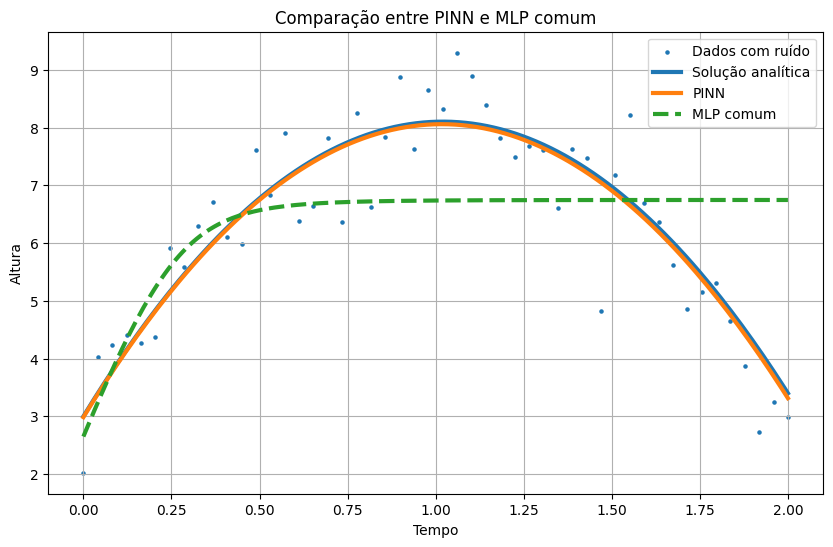

In [14]:
plt.figure(figsize=(10,6))

plt.scatter(delta_tempo, h_ruido, s=5, label='Dados com ruído')
plt.plot(t_plot, h_analitico, linewidth=3, label='Solução analítica')
plt.plot(t_plot, h_pinn, linewidth=3, label='PINN')
plt.plot(t_plot, h_mlp, '--', linewidth=3, label='MLP comum')
plt.xlabel('Tempo')
plt.ylabel('Altura')
plt.title('Comparação entre PINN e MLP comum')
plt.legend()
plt.grid(True)

plt.show()

Percebe-se que a PINN segue o padrão esperado pela solução analítica, por mais que não se sobreponha completamente. Já a MLP comum, justamente por não ser regulada pelas leis vigentes do sistema, apresenta um formato bastante diferente e fisicamente incorreto.

## 5. Como as PINNs lidam com problemas inversos?

Até agora resolvemos um problema direto, no qual a equação diferencial era conhecida e o objetivo era encontrar a solução. Em problemas inversos, o contrário ocorre, pois se tem dados observados e conhecimento parcial da física, visando descobrir parâmetros desconhecidos da equação. Ou seja, em uma equação:

$$\frac{dy}{dx}=-\lambda y$$

$\lambda$ é desconhecido, sendo o parâmetro que se procura descobrir [12]. Para verificar como fazer isso, o mesmo exemplo do lançamento será utilizado, com o objetivo de, em:

$$\frac{dh}{dt}=v_0 - gt$$

encontrar $g$, a aceleração da gravidade.

Para tanto, define-se um novo parâmetro treinável correspondente ao valor de $g$. O valor inicial escolhido foi 5.0, propositalmente diferente do valor real, permitindo verificar se a PINN consegue convergir para o parâmetro físico esperado.

In [15]:
g_treinavel_adam = torch.nn.Parameter(torch.tensor([5.0]))

Em seguida, cria-se a rede neural normalmente, e como $g$ deve ser otimizado junto aos pesos e *bias* da rede, ele é adicionado à lista de parâmetros do otimizador:

In [16]:
modelo_inverso_adam = PINN(n_hidden=20)

parametros_adam = list(modelo_inverso_adam.parameters()) + [g_treinavel_adam]

otimizador_inverso = torch.optim.Adam(parametros_adam, lr=0.01)

O processo de treinamento permanece bastante semelhante ao problema direto. A principal diferença ocorre na construção do termo físico da função de perda, pois o valor de $g$ utilizado na equação diferencial não é mais fixo, mas sim o parâmetro treinável aprendido pela PINN.

Durante o treinamento, a rede ajusta simultaneamente a aproximação da solução $h(t)$ e o valor do parâmetro físico desconhecido.

In [ ]:
modelo_inverso_adam.train()

for epoca in range(num_epocas):
    otimizador_inverso.zero_grad()

    t_dados_tensor.requires_grad_(True)

    h_prev = modelo_inverso_adam(t_dados_tensor)
    dh_dt_prev = derivada(h_prev, t_dados_tensor)

    dh_dt_real = v_i - g_treinavel_adam * t_dados_tensor

    l_fisica = torch.mean((dh_dt_prev - dh_dt_real)**2)
    l_dados = torch.mean((h_prev - h_dados_tensor)**2)

    t_i = torch.zeros(1, 1, dtype=torch.float32)

    h_i_prev = modelo_inverso_adam(t_i)

    l_ic = (h_i_prev - h_i).pow(2).mean()

    perda = lambda_dados * l_dados + lambda_fisica * l_fisica + lambda_ic * l_ic
    perda.backward()

    otimizador_inverso.step()

    if (epoca+1) % printar_a_cada == 0:

        print(
            f"[Adam] Época {epoca+1}/{num_epocas}, "
            f"Perda = {perda.item():.6f}, "
            f"g estimado = {g_treinavel_adam.item():.6f}"
        )

g_treinavel_lbfgs = torch.nn.Parameter(torch.tensor([5.0]))

modelo_inverso_lbfgs = PINN(n_hidden=20)
parametros_lbfgs = list(modelo_inverso_lbfgs.parameters()) + [g_treinavel_lbfgs]
otimizador_adam_lbfgs = torch.optim.Adam(parametros_lbfgs, lr=0.01)

modelo_inverso_lbfgs.train()

for epoca in range(num_epocas):
    otimizador_adam_lbfgs.zero_grad()

    t_dados_tensor.requires_grad_(True)

    h_prev = modelo_inverso_lbfgs(t_dados_tensor)
    dh_dt_prev = derivada(h_prev, t_dados_tensor)

    dh_dt_real = v_i - g_treinavel_lbfgs * t_dados_tensor

    l_fisica = torch.mean((dh_dt_prev - dh_dt_real)**2)
    l_dados = torch.mean((h_prev - h_dados_tensor)**2)

    t_i = torch.zeros(1, 1, dtype=torch.float32)
    h_i_prev = modelo_inverso_lbfgs(t_i)
    l_ic = (h_i_prev - h_i).pow(2).mean()

    perda = lambda_dados * l_dados + lambda_fisica * l_fisica + lambda_ic * l_ic
    perda.backward()

    otimizador_adam_lbfgs.step()

otimizador_lbfgs = torch.optim.LBFGS(parametros_lbfgs, lr=1.0, max_iter=500)

def closure():
    otimizador_lbfgs.zero_grad()
    t_dados_tensor.requires_grad_(True)

    h_prev = modelo_inverso_lbfgs(t_dados_tensor)
    dh_dt_prev = derivada(h_prev, t_dados_tensor)
    dh_dt_real = v_i - g_treinavel_lbfgs * t_dados_tensor

    l_fisica = torch.mean((dh_dt_prev - dh_dt_real)**2)
    l_dados = torch.mean((h_prev - h_dados_tensor)**2)

    t_i = torch.zeros(1, 1, dtype=torch.float32)
    h_i_prev = modelo_inverso_lbfgs(t_i)
    l_ic = (h_i_prev - h_i).pow(2).mean()

    perda = lambda_dados * l_dados + lambda_fisica * l_fisica + lambda_ic * l_ic
    perda.backward()

    return perda

otimizador_lbfgs.step(closure)

print(f"\ng real = {g_real}")
print(f"g aprendido com Adam = {g_treinavel_adam.item():.6f}")
print(f"g aprendido com Adam + L-BFGS = {g_treinavel_lbfgs.item():.6f}")

[Adam] Época 5/200, Perda = 10.153893, g estimado = 5.914545
[Adam] Época 10/200, Perda = 10.130365, g estimado = 5.926984
[Adam] Época 15/200, Perda = 10.107691, g estimado = 5.939119
[Adam] Época 20/200, Perda = 10.085783, g estimado = 5.950943
[Adam] Época 25/200, Perda = 10.064579, g estimado = 5.962450
[Adam] Época 30/200, Perda = 10.044024, g estimado = 5.973636
[Adam] Época 35/200, Perda = 10.024087, g estimado = 5.984500
[Adam] Época 40/200, Perda = 10.004752, g estimado = 5.995040
[Adam] Época 45/200, Perda = 9.986022, g estimado = 6.005260
[Adam] Época 50/200, Perda = 9.967925, g estimado = 6.015162
[Adam] Época 55/200, Perda = 9.950514, g estimado = 6.024751
[Adam] Época 60/200, Perda = 9.933844, g estimado = 6.034034
[Adam] Época 65/200, Perda = 9.917987, g estimado = 6.043016
[Adam] Época 70/200, Perda = 9.903007, g estimado = 6.051705
[Adam] Época 75/200, Perda = 9.888962, g estimado = 6.060108
[Adam] Época 80/200, Perda = 9.875889, g estimado = 6.068232
[Adam] Época 85/2

Percebe-se que a aceleração da gravidade utilizando apenas o otimizador Adam resultou em um valor bastante próximo do chute inicial de $5$ $\frac{m}{s^2}$, enquanto a utilizando Adam e L-BFGS chegou mais perto do esperado, de $9.8$ $\frac{m}{s^2}$. Mesmo assim, valor continua bastante distante. De qualquer forma, a vantagem da implementação do L-BFGS foi clara.

## 6. PINNs usando a biblioteca `DeepXDE`

Na prática, dificilmente se utilizaria PINNs para um problema tão simples quanto um lançamento vertical com apenas algumas dezenas de pontos. O exemplo anterior teve como principal objetivo introduzir os conceitos fundamentais das PINNs e mostrar como implementá-las utilizando `PyTorch`. Já sabendo disso, pode-se agora utilizar a biblioteca `DeepXDE`, pois, conforme os problemas se tornam mais complexos, a implementação manual pode rapidamente se tornar extensa e difícil. Para lidar com isso e facilitar esse processo, a `DeepXDE` será apresentada e utilizada.

A DeepXDE (*Deep learning library for solving Differential Equations*) é uma biblioteca desenvolvida especificamente para problemas envolvendo o uso de PINNs para equações diferenciais ordinárias (EDOs), equações diferenciais parciais (PDEs), problemas inversos, etc. Com o DeepXDE, é possível definir a equação diferencial, as condições iniciais e de contorno e a arquitetura da rede neural, além de especificidades do processo de treino. A biblioteca já possui integração com mecanismos de diferenciação automática, facilitando o cálculo de derivadas necessárias para os resíduos físicos. [11]

Sua importação é:

In [19]:
import deepxde as dde

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


A partir disso, para utilizar o `DeepXDE`, segue-se um fluxo como:

1. **Geometria**

Define-se o domínio físico do problema utilizando classes do módulo `dde.geometry`. Ele representa onde a equação diferencial será resolvida. Alguns exemplos são:
- `dde.geometry.Interval`: domínio unidimensional, como um intervalo espacial ou temporal;
- `dde.geometry.TimeDomain`: domínio temporal;
- `dde.geometry.Rectangle`: domínio bidimensional retangular;
- `dde.geometry.GeometryXTime`: combinação entre espaço e tempo para PDEs dependentes do tempo.

2. **Problema direto ou inverso**

Define-se a equação diferencial através de uma função que retorna o resíduo da EDO ou PDE. É justamente essa função que será minimizada pela PINN durante o treinamento.

As derivadas necessárias são calculadas via diferenciação automática utilizando:
- `dde.grad.jacobian`: derivadas de primeira ordem;
- `dde.grad.hessian`: derivadas de segunda ordem.

Em problemas inversos, parâmetros físicos desconhecidos podem ser definidos utilizando `dde.Variable`, permitindo que sejam aprendidos pela rede durante o treinamento.

3. **Condições iniciais e de contorno**

As restrições físicas do problema são impostas utilizando classes do módulo `dde.icbc`.

Alguns exemplos:
- `dde.icbc.IC`: define condições iniciais;
- `dde.icbc.DirichletBC`: impõe valores fixos da solução na fronteira;
- `dde.icbc.NeumannBC`: impõe valores da derivada na fronteira;
- `dde.icbc.PointSetBC`: utiliza dados observados experimentalmente.

4. **Construção dos dados físicos**

A geometria, a equação diferencial e as condições físicas são reunidas em objetos como o `dde.data.PDE` e o `dde.data.TimePDE`, que definem os *collocation points*, as condições físicas e o domínio no qual a PINN será treinada.

5. **Arquitetura da rede neural**

A arquitetura da rede é definida utilizando módulos de `dde.nn`. Algumas arquiteturas disponíveis:
- `dde.nn.FNN`: rede neural totalmente conectada;
- `dde.nn.PFNN`: rede parcialmente conectada;
- `dde.nn.ResNet`: arquitetura residual.

Nessa etapa definem-se número de camadas, número de neurônios, função de ativação, método de inicialização dos pesos e dimensão de entrada e saída da rede.

6. **Modelo**

O problema físico e a rede neural são combinados através de `dde.Model`, formando a PINN completa.

7. **Treinamento**

O modelo é compilado utilizando `Model.compile`, definindo o otimizador e demais parâmetros de treinamento.

Em seguida, o treinamento é realizado utilizando `Model.train`.

8. **Predição e visualização**

Após o treinamento, utiliza-se `Model.predict` para obter a solução aproximada aprendida pela PINN, permitindo comparar os resultados com soluções analíticas, dados experimentais ou métodos numéricos tradicionais. [11]

Em suma:

![aq](deepxde_guia.png)

Figura 4: Guia de possibilidades do `DeepXDE`

Fonte: https://deepxde.readthedocs.io/en/latest/

## 7. Resolvendo uma EDO com `DeepXDE`

Agora, utilizaremos o DeepXDE para resolver novamente o problema do lançamento vertical, porém com uma quantidade mais significativa de dados. A equação diferencial do sistema é a mesma anterior:

$$\frac{dh}{dt} = v_i - gt$$

com condição inicial:

$$h(0)=h_i$$

Fazendo o mesmo processo anterior de gerar dados sintéticos, porém agora com $500$ pontos:

In [20]:
t_min = 0.0
t_max = 2.0

numero_de_dados = 500

t_dados = np.linspace(t_min, t_max, numero_de_dados).reshape(-1,1)

np.random.seed(2406)

ruido = 0.7

def solucao_analitica(t):
    return (h_i + v_i*t - 0.5*g_real*(t**2))

h_exato = solucao_analitica(t_dados)
h_ruido = (h_exato + ruido*np.random.randn(numero_de_dados, 1))

Para transformar $g$ em treinável, utiliza-se a função `Variable` do `DeepXDE`:

In [21]:
g = dde.Variable(5.0)

Agora, define-se a equação diferencial. O `DeepXDE` já realiza a diferenciação automática internamente ao utilizar o `grad.jacobian`.

In [22]:
def edo(t, h):
    dh_dt = dde.grad.jacobian(h,t)
    return dh_dt - (v_i - g*t)

Em seguida, define-se o domínio em questão usando `TimeDomain`:

In [23]:
dominio = dde.geometry.TimeDomain(t_min, t_max)

Define-se a condição inicial utilizando a classe `icbc.IC`, que recebe o domínio, uma função que descreve o valor da condição e uma função lógica que indica onde a condição deve ser aplicada.

In [24]:
condicao_inicial = dde.icbc.IC(dominio, lambda t: h_i, lambda _, on_initial: on_initial)

Para informar à PINN os pontos de entrada:

In [25]:
observacoes = dde.icbc.PointSetBC(t_dados, h_ruido)

A próxima etapa reúne todas as informações físicas do problema em um único objeto. Os argumentos representam:
- `dominio`: região onde a equação será resolvida;
- `edo`: função que define o resíduo da equação diferencial;
- `[condicao_inicial, observacoes]`: condições físicas e dados experimentais;
- `num_domain`: quantidade de *collocation points*;
- `num_boundary`: quantidade de pontos utilizados na fronteira do domínio.

In [26]:
dados = dde.data.PDE(dominio, edo, [condicao_inicial, observacoes], num_domain=200, num_boundary=2)

Agora, define-se a arquitetura da rede neural com a classe `nn.FNN` (*Fully connected Neural Network*). Pode-se determinar a estrutura por um esquema de lista:

In [27]:
rede = dde.nn.FNN([1] + [20]*2 + [1], "tanh", "Glorot normal")

Acima, na lista $[1] + [20]*2 + [1]$, $[1]$ indica que há 1 neurônio de entrada, $[20]*2$ mostra que há duas camadas ocultas com $20$ neurônios cada, e o $[1]$ final indica que há 1 saída. A classe também recebe a função de ativação (`tanh`) e a forma de inicialização dos pesos iniciais da redes (`Glorot normal`).

Com tudo isso feito, pode-se passar para o modelo completo:

In [28]:
modelo_edo_xde = dde.Model(dados, rede)

Inicialmente, utiliza-se o otimizador Adam com a função `compile`.


In [29]:
modelo_edo_xde.compile("adam", lr=0.01, external_trainable_variables=[g])

Compiling model...
'compile' took 0.000421 s



Realizando o treinamento:

In [30]:
modelo_edo_xde.train(epochs=1000)

Training model...

Step      Train loss                        Test loss                         Test metric
0         [3.24e+01, 9.00e+00, 4.19e+01]    [3.24e+01, 9.00e+00, 4.19e+01]    []  
1000      [2.85e-01, 4.41e-02, 8.35e-01]    [2.85e-01, 4.41e-02, 8.35e-01]    []  

Best model at step 1000:
  train loss: 1.16e+00
  test loss: 1.16e+00
  test metric: []

'train' took 1.654712 s



(<deepxde.model.LossHistory at 0x16b41064b90>,
 <deepxde.model.TrainState at 0x16b41578530>)

Aplicando o refinamento com L-BFGS:

In [31]:
modelo_edo_xde.compile("L-BFGS", external_trainable_variables=[g])

modelo_edo_xde.train()

Compiling model...
'compile' took 0.000612 s

Training model...

Step      Train loss                        Test loss                         Test metric
1000      [2.85e-01, 4.41e-02, 8.35e-01]    [2.85e-01, 4.41e-02, 8.35e-01]    []  
1178      [5.41e-04, 2.24e-04, 4.80e-01]    [5.41e-04, 2.24e-04, 4.80e-01]    []  

Best model at step 1178:
  train loss: 4.81e-01
  test loss: 4.81e-01
  test metric: []

'train' took 0.607198 s



(<deepxde.model.LossHistory at 0x16b41064b90>,
 <deepxde.model.TrainState at 0x16b41578530>)

Agora compara-se o valor aprendido pela PINN com o valor real utilizado na geração dos dados.

In [32]:
g_real = 9.8

print(f"\ng real = {g_real}")

print(
    f"g aprendido = "
    f"{g.item():.6f}"
)


g real = 9.8
g aprendido = 9.779707


Percebe-se que, aumentando o número de dados nesse exemplo, o valor de $g$ aprendido se aproximou bem mais do real.

Por fim, visualiza-se a solução aprendida pela PINN.

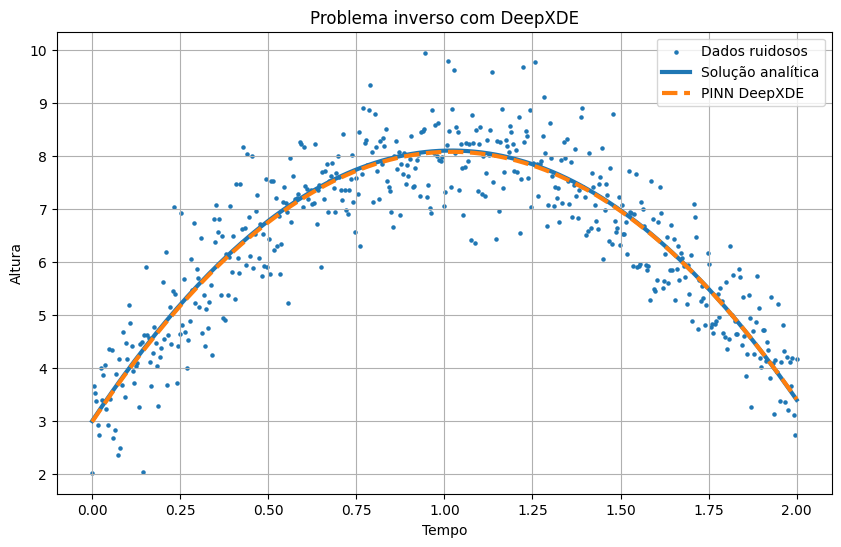

In [33]:
t_plot = np.linspace(t_min, t_max, 200).reshape(-1,1)

h_pinn = modelo_edo_xde.predict(t_plot)
h_real = solucao_analitica(t_plot)

plt.figure(figsize=(10,6))

plt.scatter(t_dados, h_ruido, s=5, label='Dados ruidosos')
plt.plot(t_plot, h_real, linewidth=3, label='Solução analítica')
plt.plot(t_plot, h_pinn, '--', linewidth=3, label='PINN DeepXDE')

plt.xlabel('Tempo')
plt.ylabel('Altura')
plt.title('Problema inverso com DeepXDE')
plt.legend()

plt.grid(True)

plt.show()

Nota-se que a PINN se sobrepõe à solução analítica, adequando-se tanto à solução quanto à física da situação.

## 8. Resolvendo uma PDE com `DeepXDE`

Até agora, estávamos lidando com uma ODE. Mas também pode-se estabelecer como restrição uma equação diferencial parcial (PDE). Aqui será utilizada a equação do calor unidimensional, já mencionada anteriormente:

$$\frac{\partial u}{\partial t} = \alpha\frac{\partial^2 u}{\partial x^2}$$

onde $u(x,t)$ representa a temperatura, $\alpha$ é a difusividade térmica, $x$ representa a posição espacial e $t$ representa o tempo [5].

A condição inicial será:

$$u(x,0)=\sin(\pi x)$$

E as condições de contorno:

$$u(0,t)=0$$

$$u(1,t)=0$$

Em métodos tradicionais, seria necessário discretizar espaço e tempo utilizando malhas numéricas, o que não ocorre aqui, pois as PINNs não dependem explicitamente de uma malha estruturada. Escolhendo um valor arbitrário de difusividade térmica.

In [34]:
alpha = 0.4

Primeiramente, define-se a geometria do problema. Diferentemente da EDO anterior, agora existe tanto um domínio espacial quanto um temporal.

O domínio espacial será:

$$x\in[0,1]$$

e o temporal:

$$t\in[0,1]$$

O `DeepXDE` combina ambos utilizando `GeometryXTime`.

In [35]:
geom = dde.geometry.Interval(0, 1)

timedomain = dde.geometry.TimeDomain(0, 1)

geomtime = dde.geometry.GeometryXTime(geom, timedomain)

Definindo o resíduo da PDE:

`du_t` representa:

$$\frac{\partial u}{\partial t}$$

E `du_xx` representa:

$$\frac{\partial^2u}{\partial x^2}$$

A PINN tentará minimizar o resíduo:

$$\frac{\partial u}{\partial t}-\alpha\frac{\partial^2u}{\partial x^2}=0$$

In [36]:
def pde(x, u):
    du_t = dde.grad.jacobian(u, x, i=0, j=1)
    du_xx = dde.grad.hessian(u, x, i=0, j=0)

    return du_t - alpha * du_xx

Agora impõem-se as condições de contorno.

Neste caso, as extremidades da barra permanecem com temperatura nula:

$$u(0,t)=0$$

$$u(1,t)=0$$

Utiliza-se `DirichletBC`, que fixa o valor da solução na fronteira.

In [37]:
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

Também é necessário impor a condição inicial:

In [38]:
ic = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial)

Agora todas as informações físicas do problema são reunidas em um objeto `TimePDE`.

In [ ]:
data = dde.data.TimePDE(geomtime, pde, [bc, ic], num_domain=2540, num_boundary=80, num_initial=160)

Em seguida, define-se a rede neural. Como agora a entrada possui posição e tempo, a camada de entrada possui dimensão 2. A saída continua sendo escalar, representando a temperatura prevista. Optou-se por mais uma camada oculta, e cada uma com mais neurônios devido ao aumento de dificuldade representado por uma PDE.

In [40]:
rede_pde = dde.nn.FNN([2] + [40]*3 + [1], "tanh", "Glorot normal")

Pode-se, então, definir o modelo completo da PINN:

In [41]:
modelo_pde = dde.Model(data, rede_pde)

O treinamento também será realizado primeiro com Adam e depois com L-BFGS.

In [42]:
modelo_pde.compile("adam", lr=0.01)
losshistory, train_state = modelo_pde.train(epochs=1000)

modelo_pde.compile("L-BFGS")
losshistory, train_state = modelo_pde.train()

Compiling model...
'compile' took 0.000249 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [7.78e-02, 5.55e-02, 6.18e-01]    [7.78e-02, 5.55e-02, 6.18e-01]    []  
1000      [2.07e-04, 3.12e-05, 3.43e-05]    [2.07e-04, 3.12e-05, 3.43e-05]    []  

Best model at step 1000:
  train loss: 2.72e-04
  test loss: 2.72e-04
  test metric: []

'train' took 7.716546 s

Compiling model...
'compile' took 0.000286 s

Training model...

Step      Train loss                        Test loss                         Test metric
1000      [2.07e-04, 3.12e-05, 3.43e-05]    [2.07e-04, 3.12e-05, 3.43e-05]    []  
1349      [9.82e-07, 2.03e-07, 5.09e-08]    [9.82e-07, 2.03e-07, 5.09e-08]    []  

Best model at step 1349:
  train loss: 1.24e-06
  test loss: 1.24e-06
  test metric: []

'train' took 3.399441 s



Após o treinamento, gera-se uma malha de pontos para visualizar a solução aprendida pela PINN.

In [45]:
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)

XT = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

Agora a rede prevê a temperatura em cada ponto do domínio:

In [46]:
U = modelo_pde.predict(XT)
U = U.reshape(100, 100)

Por fim, visualiza-se a evolução temporal da temperatura ao longo da barra.

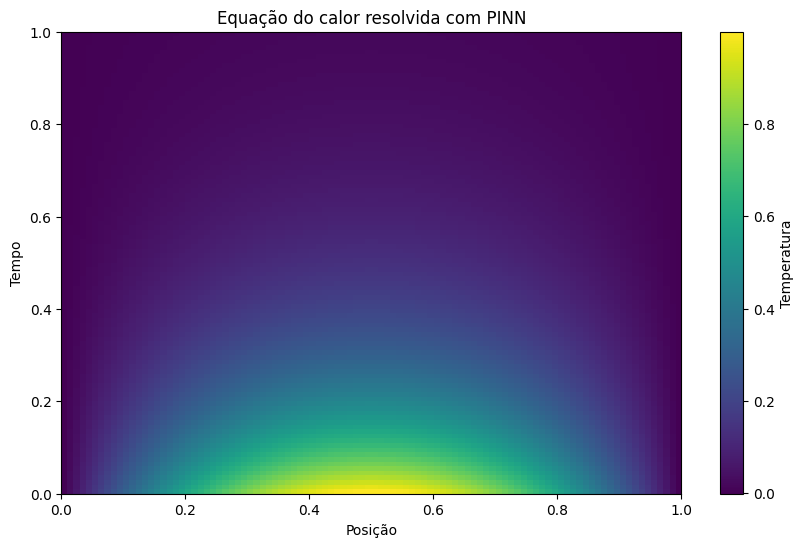

In [47]:
plt.figure(figsize=(10,6))

plt.imshow(U, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar(label='Temperatura')
plt.xlabel('Posição')
plt.ylabel('Tempo')
plt.title('Equação do calor resolvida com PINN')

plt.show()

O resultado obtido acima faz sentido fisicamente para a equação do calor. Observa-se que, no instante inicial a temperatura é máxima na região central da barra e nula nas extremidades, exatamente como definido pela condição inicial e pelas condições de contorno.

À medida que o tempo evolui, a temperatura se difunde pela barra e sua amplitude vai diminuindo. Esse comportamento é esperado, pois a equação do calor descreve justamente a dissipação gradual de energia térmica.

Isso indica que a PINN conseguiu aprender corretamente a dinâmica difusiva da PDE. O comportamento observado também é compatível com a solução analítica:

$$u(x,t)=e^{-\alpha\pi^2 t}\sin(\pi x)$$

na qual o termo exponencial controla o decaimento temporal da temperatura.

## 9. Limitações das PINNs

Embora as PINNs sejam uma abordagem promissora para problemas científicos, isso não as isenta de limitações. Na prática, muitos problemas continuam sendo difíceis de resolver mesmo utilizando redes neurais informadas por física.

### 9.1. *Spectral Bias*

O fenômeno *spectral bias* descreve a tendência das redes neurais aprenderem primeiro componentes de baixa frequência antes de aprender padrões de alta frequência. Isto é, estruturas suaves são aprendidas rapidamente, enquanto oscilações rápidas são aprendidas lentamente [13].

Isso é particularmente problemático em PINNs porque muitas soluções físicas apresentam oscilações e estruturas com múltiplas escalas diferentes. Mesmo que a rede tenha capacidade suficiente para representar a solução, o treinamento pode falhar em capturar corretamente essas regiões. A fim de exemplificar, considerando as funções:

$$f_1(x)=\sin(x)$$

e

$$f_2(x)=\sin(20x)$$

A função $f_1(x)$ possui baixa frequência e normalmente é aprendida facilmente por redes neurais. Já $f_2(x)$ oscila rapidamente e costuma ser muito mais difícil de aprender [14]. Mesmo utilizando a mesma arquitetura, a convergência para funções altamente oscilatórias pode ser extremamente lenta.

Esse problema pode gerar suavização artificial da solução, incapacidade de capturar choques, erros elevados em regiões localizadas e convergência aparentemente boa da perda, mas solução física incorreta. Diversas estratégias têm sido propostas para reduzir o *spectral bias*, como ativações periódicas e arquiteturas mais profundas. [14]

### 9.2. *Stiff Differential Equations*

Outro grande desafio em PINNs envolve as chamadas *stiff differential equations*. Uma equação diferencial é considerada *stiff* quando diferentes componentes da solução evoluem em escalas muito distintas. Isso gera grande dificuldade para métodos numéricos e também para redes neurais [15].

Em PINNs, equações *stiff* frequentemente produzem gradientes instáveis, treinamento extremamente lento, dificuldade de convergência e sensibilidade à escolha da taxa de aprendizagem [16]. Além disso, a perda física pode ficar mal condicionada, dificultando a otimização. Esse é um dos motivos pelos quais a escolha otimizadores é tão importantes em PINNs, já que remediam esse problema.

### 9.3. *Curse of Dimensionality*

Outro desafio é a chamada *curse of dimensionality*. Esse termo descreve o crescimento exacerbado da complexidade computacional à medida que aumentamos a dimensionalidade do problema [17]. Em métodos tradicionais, aumentar o número de dimensões frequentemente implica crescimento exponencial do número de pontos necessários na discretização. Ou seja, enquanto uma uma malha 1D pode exigir $100$ pontos, uma 2D pode $100^2$, e assim por diante.

Já as PINNs possuem uma vantagem importante: elas são métodos *mesh-free*. Ou seja, não dependem explicitamente de uma malha. Isso faz com que PINNs frequentemente escalem melhor que métodos clássicos em problemas de alta dimensionalidade. 

Embora reduzam parcialmente a maldição da dimensionalidade, ela ainda existe. À medida que a dimensão cresce mais pontos de collocation são necessários, o treinamento fica mais difícil, a otimização se torna mais instável e o custo computacional aumenta significativamente [17]. Além disso, redes maiores passam a ser necessárias para representar soluções complexas.

## Conclusão

Este notebook introduziu as *Physics-Informed Neural Networks* (PINNs), desde seus fundamentos teóricos até aplicações práticas com a biblioteca `DeepXDE`. Foi visto que a principal inovação dessa abordagem é incorporar o conhecimento das leis físicas, na forma de equações diferenciais, diretamente na função de custo da rede neural. Isso permite obter soluções fisicamente consistentes mesmo em cenários com dados escassos ou ruidosos, superando uma limitação fundamental das redes neurais tradicionais e métodos numéricos.

Através da implementação manual com `PyTorch` no problema do lançamento oblíquo, pôde-se compreender os componentes essenciais de uma PINN, como a diferenciação automática para calcular os resíduos, a combinação de múltiplos termos na função de perda e a importância do otimizadores L-BFGS para refinar a solução.

O uso do DeepXDE demonstrou como essa biblioteca facilita parte da complexidade computacional, permitindo foco na formulação do problema físico. A resolução da equação do calor unidimensional ilustrou o potencial das PINNs para lidar com Equações Diferenciais Parciais (PDEs) sem malha.

No entanto, como o próprio professor doutor José Mario Martínez aponta, as PINNs não são uma solução universal. Limitações como o *spectral bias*, a instabilidade em equações *stiff* e o aumento da complexidade computacional em altas dimensionalidades ainda são desafios abertos.

Em suma, as PINNs consolidam-se como uma ferramenta poderosa, servindo como uma ferramenta para solucionar equações diferenciais, encontrar constantes físicas e realizar previsões de forma a obedecer restrições do próprio problema.

## Referências

[1] MATHWORKS. Physics-Informed Neural Networks. Disponível em: https://www.mathworks.com/discovery/physics-informed-neural-networks.html. Acesso em: 10 abr. 2026.

[2] CERQUEIRA, Pedro Henrique da Silva Singue. A state-of-the-art of physics-informed neural networks in engineering. 2021. Trabalho de Conclusão de Curso (Graduação em Engenharia Química) - Escola de Química, Universidade Federal do Rio de Janeiro, Rio de Janeiro, 2021.

[3] CLAUDIO, João. O que é uma Physics-Informed Neural Network (PINN). Medium, [s.d.]. Disponível em:
https://joaoclaudionc.medium.com/o-que-%C3%A9-uma-physics-informed-neural-network-pinn-3d0d466693f9.
Acesso em: 10 abr. 2026.

[4] PANAT, Sreedath; VIZUARA AI LABS. Teach your neural network to "respect" Physics: Physics Informed Neural Networks (PINN). Vizuara’s AI Newsletter, 23 fev. 2025. Disponível em: https://www.vizuaranewsletter.com/p/teach-your-neural-network-to-respect. Acesso em: 9 maio 2026.

[5] EQUAÇÃO do calor. In: WIKIPÉDIA: a enciclopédia livre. [S. l.]. Disponível em: https://pt.wikipedia.org/wiki/Equa%C3%A7%C3%A3o_do_calor. Acesso em: 9 maio 2026.

[6] GRIGORIAN, Vardan. Understanding Physics-Informed Neural Networks (PINNs) - Part 1. Medium, 27 jan. 2024. Disponível em: https://thegrigorian.medium.com/understanding-physics-informed-neural-networks-pinns-part-1-8d872f555016. Acesso em: 10 maio 2026.

[7] GILBERT, Sébastien. Taming PINNs: how hard constraints make neural networks obey physics. Medium, 1 out. 2025. Disponível em: https://medium.com/data-science-collective/taming-pinns-how-hard-constraints-make-neural-networks-obey-physics-7d78e5b9f7a5. Acesso em: 10 abr. 2026.

[8] BISCHOF, Rafael. 10 useful hints and tricks for improving physics-informed neural networks (PINNs). Medium, 8 fev. 2023. Disponível em: https://medium.com/data-science/10-useful-hints-and-tricks-for-improving-pinns-1a5dd7b86001. Acesso em: 10 abr. 2026.

[9] SÁ, Pedro Brito de. Physics-Informed-Neural-Network-Project. GitHub, [202-]. Disponível em: https://github.com/PedroBritodSa/Physics-Informed-Neural-Network-Project. Acesso em: 11 maio 2026.

[10] SINGH, Deepankar. Mastering tanh: a deep dive into balanced activation for machine learning. Medium, ano. Disponível em: https://medium.com/ai-enthusiast/mastering-tanh-a-deep-dive-into-balanced-activation-for-machine-learning-4734ec147dd9. Acesso em: 9 maio 2026.

[11] DEEPXDE documentation. Read the Docs, [202-]. Disponível em: https://deepxde.readthedocs.io/en/latest/. Acesso em: 10 abr. 2026.

[12] SOLVE inverse problem for PDE using physics-informed neural network. MathWorks, [2025]. Disponível em: https://www.mathworks.com/help/deeplearning/ug/solve-inverse-problem-for-pde-using-physics-informed-neural-network.html. Acesso em: 11 maio 2026.

[13] KHODAKARAMI, Siavash et al. Spectral bias in physics-informed and operator learning: analysis and mitigation guidelines. arXiv, 2026. DOI: 10.48550/arXiv.2602.19265. Disponível em: https://doi.org/10.48550/arXiv.2602.19265. Acesso em: 11 maio 2026.

[14] CHAI, Xintao et al. Overcoming the spectral bias problem of physics-informed neural networks in solving the frequency-domain acoustic wave equation. IEEE Transactions on Geoscience and Remote Sensing, v. 62, 2024. DOI: 10.1109/TGRS.2024.3440471. Disponível em: https://ieeexplore.ieee.org/document/10630853. Acesso em: 11 maio 2026.

[15] STIFF-PINN. Emergent Mind, [202-]. Disponível em: https://www.emergentmind.com/topics/stiff-pinn. Acesso em: 11 maio 2026.

[16] NASIRI, Pouyan; DARGAZANY, Roozbeh. Reduced-PINN: an integration-based physics-informed neural networks for stiff ODEs. arXiv, 2022. DOI: 10.48550/arXiv.2208.12045. Disponível em: https://doi.org/10.48550/arXiv.2208.12045. Acesso em: 11 maio 2026.

[17] HU, Zheyuan et al. Tackling the curse of dimensionality with physics-informed neural networks. Neural Networks, v. 176, p. 106369, 2024. DOI: 10.1016/j.neunet.2024.106369. Disponível em: https://doi.org/10.1016/j.neunet.2024.106369. Acesso em: 11 maio 2026.

CASSAR, Daniel Roberto. Construindo e treinando redes neurais com PyTorch e Lightning. [Jupyter Notebook], Ilum - Escola de Ciência, Campinas, 2026.

LU, Lu et al. DeepXDE. GitHub. Disponível em: https://github.com/lululxvi/deepxde. Acesso em: 10 abr. 2026.

PHYSICS-informed neural networks. In: WIKIPEDIA: the free encyclopedia. [S. l.], [202-]. Disponível em: https://en.wikipedia.org/wiki/Physics-informed_neural_networks. Acesso em: 10 abr. 2026.

PYTORCH ORGANIZATION. torch.optim.LBFGS - PyTorch documentation. Disponível em: https://docs.pytorch.org/docs/stable/generated/torch.optim.LBFGS.html#torch.optim.LBFGS. Acesso em: 9 maio 2026.

WOLF, Theo. Physics-informed neural networks: a simple tutorial with PyTorch. Medium, 13 abr. 2023. Disponível em: https://medium.com/@theo.wolf/physics-informed-neural-networks-a-simple-tutorial-with-pytorch-f28a890b874a. Acesso em: 10 abr. 2026.